# Project Two - Sampling

**New York University Abu Dhabi**  
**Probability and Statistics - Fall 2026**

This project analyzes a public dataset. Complete every exercise in this notebook using your chosen dataset and numerical feature. Keep your explanations, executable code, and plots together.


## Team and dataset information

Replace the prompts below before submitting.

- **Team name:** Probably Correct
- **Team members:** Junius, Dasha, Fatima Zahra
- **Dataset name:** AirQualityUCI
- **Chosen numerical feature:** C6H6(GT) Benzene concentration (µg/m³)
- **Population size:** 8991 Observations

## Environment and setup


In [44]:
#Standard libraries
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

#Reproducibility
RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)

### Load and validate the data

Adapt the template to the file type you selected. Define `dataset` as the population table.


In [45]:
from google.colab import files
uploaded = files.upload()
dataset = pd.read_excel("AirQualityUCI.xlsx")
dataset.head()

Saving AirQualityUCI.xlsx to AirQualityUCI (4).xlsx


,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
0,2004-03-10,18:00:00,2.6,1360.00,150,11.881723,1045.50,166.0,1056.25,113.0,1692.00,1267.50,13.60,48.875001,0.757754
1,2004-03-10,19:00:00,2.0,1292.25,112,9.397165,954.75,103.0,1173.75,92.0,1558.75,972.25,13.30,47.700000,0.725487
2,2004-03-10,20:00:00,2.2,1402.00,88,8.997817,939.25,131.0,1140.00,114.0,1554.50,1074.00,11.90,53.975000,0.750239
3,2004-03-10,21:00:00,2.2,1375.50,80,9.228796,948.25,172.0,1092.00,122.0,1583.75,1203.25,11.00,60.000000,0.786713
4,2004-03-10,22:00:00,1.6,1272.25,51,6.518224,835.50,131.0,1205.00,116.0,1490.00,1110.00,11.15,59.575001,0.788794


We repeat the same **data preprocessing** steps we went through in Project One to work with the clean dataset. The dataset represents missing measurements of Benzene using a value of (-200)

In [46]:
dataset = dataset[dataset["C6H6(GT)"] != -200]
print(f"{len(dataset)} is the population size")

8991 is the population size


The probability experiment is to select one valid hourly observation uniformly at random from the cleaned dataset and observe its C6H6(GT) value.

---

## Exercise 1 - The feature as a random variable

Let $\Omega$ be the population space of the dataset. Consider the probability space $(\Omega, 2^\Omega, \mu)$, where $\mu$ is the uniform measure on $\Omega$. Let

$$
X:\Omega\to\mathbb{R}, \qquad \omega\mapsto\text{feature value of }\omega.
$$

Is $X$ a random variable? Justify your answer.


**Answer.**

Let

$$
\Omega=\{\omega_1,\omega_2,\ldots,\omega_{8991}\}
$$

be the population space consisting of the $8991$ valid hourly observations
in the cleaned dataset.

Consider the probability space

$$
\left(\Omega,2^\Omega,\mu\right),
$$

where $2^\Omega$ is the power set of $\Omega$ and

$$
\mu(A)=\frac{|A|}{|\Omega|}
\qquad
\text{for every }A\subseteq\Omega.
$$

Define the feature map

$$
X:\Omega\longrightarrow\mathbb{R},
\qquad
\omega\longmapsto X(\omega),
$$

where $X(\omega)$ is the `C6H6(GT)` benzene concentration associated
with observation $\omega$.

A real-valued function $X$ is a random variable if it is measurable.
Therefore, we must verify that, for every Borel set

$$
B\in\mathrm{Borel}(\mathbb{R}),
$$

the inverse image of $B$ under $X$ belongs to the $\sigma$-algebra $2^\Omega$.

The inverse image is

$$
X^{-1}(B)
=
\{\omega\in\Omega:X(\omega)\in B\}.
$$

For every Borel set $B\in\mathrm{Borel}(\mathbb{R})$, the preimage
$X^{-1}(B)$ consists of points of $\Omega$, since $X$ is defined on $\Omega$. Thus

$$
X^{-1}(B)\subseteq\Omega.
$$


Since $2^\Omega$ contains every subset of $\Omega$,

$$
X^{-1}(B)\in2^\Omega.
$$

Therefore, $X$ is measurable as a function

$$
X:
\left(\Omega,2^\Omega\right)
\longrightarrow
\left(\mathbb{R},\mathrm{Borel}(\mathbb{R})\right).
$$

Therefore,

$$
X\text{ is a random variable.}
$$

---

## Exercise 2 - Population CDF

Let

$$
F_X(x)=\frac{1}{|\Omega|}\sum_{\omega\in\Omega}\mathbf{1}_{\{X(\omega)\le x\}}, \qquad x\in\mathbb{R}.
$$

Plot $F_X$, describe the construction and interpret the plot


**Plot.**

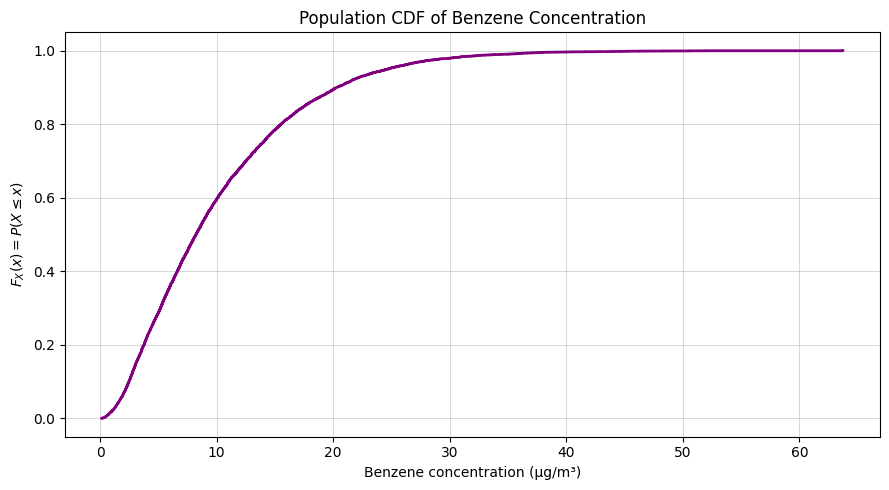

In [47]:
benzene = dataset["C6H6(GT)"].to_numpy() #Benzene Concentration

# Step 1: Sort the values of the benzene from smallest to largest
benzene_sorted = np.sort(benzene)

# Step 2: We compute Fx(x) at every value x in the benzene_sorted
# get the value of the denominator
sample_size = len(benzene_sorted)

# get the value of the numerator
Fx_values = []
for benzene_value in benzene_sorted:
    Fx_value = np.sum(benzene_sorted <= benzene_value)
    Fx_values.append(Fx_value)

cdf_values = [value / sample_size for value in Fx_values]

# Step 3: We plot the population CDF
fig, ax = plt.subplots(figsize=(9, 5))

ax.step(
    benzene_sorted,
    cdf_values,
    where= "post",
    color= "purple",
    linewidth=2)

ax.set_xlabel("Benzene concentration (µg/m³)")
ax.set_ylabel(r"$F_X(x)=P(X\leq x)$")
ax.set_title("Population CDF of Benzene Concentration")
ax.grid(True,
    linewidth=0.7,
    alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

**Answer and Interpretation.**

- **Mathematical Observation**

Let

$$
|\Omega|=8991.
$$

We define

$$
F_X(x)
=
\frac{1}{8991}\sum_{\omega\in\Omega}\mathbf{1}_{\{X(\omega)\leq x\}}
=
\frac{\left|\{\omega\in\Omega:X(\omega)\leq x\}\right|}{8991},
\qquad x\in\mathbb{R}.
$$

The function $F_X$ is a cumulative distribution function, since it satisfies the following four properties.

#### 1. Values in $[0,1]$

For every $x\in\mathbb{R}$,

$$
0
\leq
\left|\{\omega\in\Omega:X(\omega)\leq x\}\right|
\leq
8991.
$$

Since $8991>0$, dividing by $8991$ gives

$$
0\leq F_X(x)\leq1.
$$

#### 2. Nondecreasing

Let $x_1,x_2\in\mathbb{R}$ with $x_1\leq x_2$. Then

$$
\{\omega\in\Omega:X(\omega)\leq x_1\}
\subseteq
\{\omega\in\Omega:X(\omega)\leq x_2\}.
$$

Therefore,

$$
\left|\{\omega\in\Omega:X(\omega)\leq x_1\}\right|
\leq
\left|\{\omega\in\Omega:X(\omega)\leq x_2\}\right|.
$$

Dividing by $8991$, we obtain

$$
F_X(x_1)\leq F_X(x_2).
$$

Thus, $F_X$ is nondecreasing.

#### 3. Right-continuity

Since $\Omega$ is finite, $X$ takes only finitely many values.

Let $x\in\mathbb{R}$. Then there exists $\delta>0$ such that no value of $X$
lies in $(x,x+\delta)$. Hence, for every $t\in[x,x+\delta)$,

$$
\{\omega\in\Omega:X(\omega)\leq t\}
=
\{\omega\in\Omega:X(\omega)\leq x\},
$$

so $F_X(t)=F_X(x)$. Consequently,

$$
\lim_{t\downarrow x}F_X(t)=F_X(x).
$$

Thus, $F_X$ is right-continuous.

#### 4. Limits at infinity

Let

$$
L=\min_{\omega\in\Omega}X(\omega)
\qquad\text{and}\qquad
H=\max_{\omega\in\Omega}X(\omega).
$$

In this dataset, $L=0.149$ and $H=63.741$ (in $\mu\mathrm{g}/\mathrm{m}^3$).

If $x<L$, no observation satisfies $X(\omega)\leq x$. Hence

$$
F_X(x)=0
\qquad\text{for every }x<L.
$$

Therefore,

$$
\lim_{x\to-\infty}F_X(x)=0.
$$

If $x\geq H$, every observation satisfies $X(\omega)\leq x$. Hence

$$
F_X(x)=\frac{8991}{8991}=1
\qquad\text{for every }x\geq H.
$$

Therefore,

$$
\lim_{x\to+\infty}F_X(x)=1.
$$

Since $F_X$ takes values in $[0,1]$, is nondecreasing and right-continuous,
and has limits $0$ and $1$ at $-\infty$ and $+\infty$ respectively,
$F_X$ is a cumulative distribution function.

#### Discrete nature of the CDF

Under the finite-population model, every individual observation has probability

$$
\mu(\{\omega_i\})=\frac{1}{8991}\approx0.0001112.
$$

For a value $a\in\mathbb{R}$, let

$$
m(a)=\left|\{\omega\in\Omega:X(\omega)=a\}\right|.
$$

The jump of the CDF at $a$ is

$$
F_X(a)-F_X(a^-)=\mu(X=a)=\frac{m(a)}{8991},
$$

where $F_X(a^-)=\lim_{t\uparrow a}F_X(t)$.

If the value $a$ occurs once, the jump is

$$
\frac{1}{8991}\approx0.0001112.
$$

If it occurs $m$ times, the jump is

$$
\frac{m}{8991}.
$$

Therefore, $F_X$ is mathematically a step function. However, the large number
of small and closely spaced jumps makes the plotted CDF appear approximately
smooth.

- **Analytical Observation**

For every $$ x\in\mathbb{R} $$

$$
F_X(x)=P(X\leq x)
$$

represents the proportion of the \(8991\) hourly observations whose benzene
concentration is less than or equal to \(x\).

Reading approximate values from the graph,

$$
F_X(10)\approx0.60.
$$

Thus, approximately \(60\%\) of the observations have benzene
concentrations less than or equal to

$$
10\ \mu\mathrm{g}/\mathrm{m}^3.
$$

Similarly,

$$
F_X(20)\approx0.90,
$$

meaning that approximately \(90\%\) of the observations have concentrations
less than or equal to

$$
20\ \mu\mathrm{g}/\mathrm{m}^3.
$$

Also,

$$
F_X(30)\approx0.98,
$$

so approximately \(98\%\) of the observations have concentrations less
than or equal to

$$
30\ \mu\mathrm{g}/\mathrm{m}^3.
$$

The CDF increases rapidly at relatively low concentration values. This
indicates that a large proportion of the observations is concentrated in
the lower part of the observed range.

After approximately

$$
30\ \mu\mathrm{g}/\mathrm{m}^3,
$$

the CDF becomes nearly flat. Therefore, only a small proportion of the
observations has benzene concentrations above this value.

Although the maximum observed concentration is approximately

$$
63.741\ \mu\mathrm{g}/\mathrm{m}^3,
$$

very few observations occur near this upper extreme. Thus, the observed
benzene distribution is concentrated at lower values and has a long upper
tail, which is consistent with a right-skewed distribution.

## Exercise 3 - Histogram

Plot the histogram of the feature. What is the relation between this histogram and $F_X$?

**Plot.**

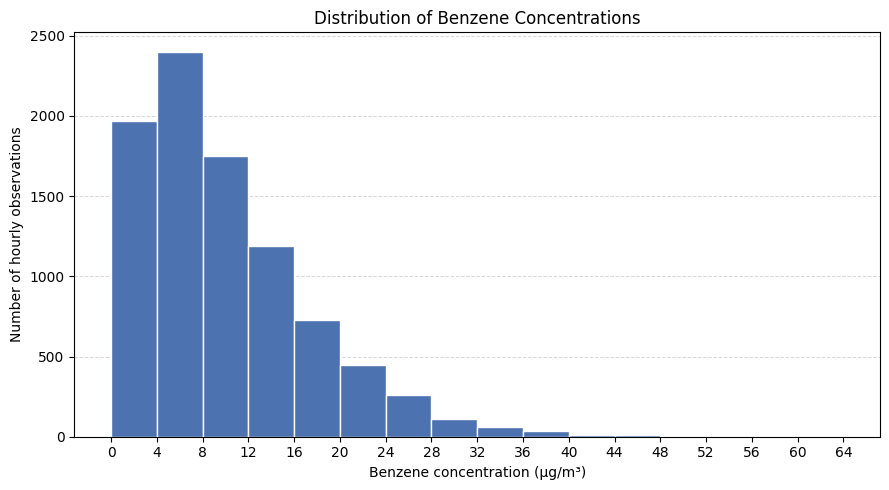

In [48]:
# OpenStax histogram guide was used to plot the histogram
# https://openstax.org/books/introductory-statistics-2e/pages/2-2-histograms-frequency-polygons-and-time-series-graphs

# 1. We calculate the minimum, maximum, and range of the observed values
L = benzene.min()
H = benzene.max()
data_range = H - L

# 2. We choose the desired number of bins
number_of_bins = 15

# 3. We calculate the bin width and round it to a convenient value
calculated_bin_width = data_range / number_of_bins
bin_width = round(calculated_bin_width)

# We generate equal-width bin edges that cover the observed range
lower_edge = np.floor(L / bin_width) * bin_width
upper_edge = np.ceil(H / bin_width) * bin_width
bin_edges = np.arange(lower_edge, upper_edge + bin_width, bin_width)

# 4. We plot the count histogram using the manually selected bins
fig, ax = plt.subplots(figsize=(9, 5))

ax.hist(
    benzene,
    bins=bin_edges,
    color="#4C72B0",
    edgecolor="white"
)

ax.set_xlabel("Benzene concentration (µg/m³)")
ax.set_ylabel("Number of hourly observations")
ax.set_title("Distribution of Benzene Concentrations")
ax.set_xticks(bin_edges)
ax.grid(True, axis="y", linestyle="--", linewidth=0.7, alpha=0.5)
ax.set_axisbelow(True)

plt.tight_layout()
plt.show()

**Answer and Interpretation.**  
- **Bin choice** The procedure used to choose the number and width of the bins is explained in the code comments above. Therefore, Matplotlib uses its default value, `density = False`. We targeted 15 bins, which gives a width of $(H-L)/15\approx4.24$. This was rounded to $4\ \mu\mathrm{g}/\mathrm{m}^3$, and the edges were extended to the integer multiples
of $4$ covering the range, namely $0,4,\dots,64$. This gives $16$ bins of equal width. The histogram displays observation counts because density was not specified.
The bar heights are observation counts, not densities.
- **Histogram and the population CDF**

For a concentration $x$, the CDF plot shows

$$
F_X(x)=\mu(X\leq x),
$$

the proportion of the $8991$ observations with $X\leq x$. The histogram instead
shows how many observations fall in each bin $[b_j,b_{j+1})$.

The two are directly related. If $n_j$ is the count of bin $j$, then

$$
\frac{n_j}{|\Omega|}=\mu\big(b_j\leq X<b_{j+1}\big)=F_X(b_{j+1}^-)-F_X(b_j^-).
$$

So the normalized height of each bar is the increment of $F_X$ across that bin.
Equivalently, $F_X$ at a point is the cumulative sum of the normalized bar
heights up to that point (up to the bin edges), and the histogram is a discrete
version of the derivative of $F_X$.

- **Observation on the data**

The tallest bars are at low concentrations, which is exactly where $F_X$ rises
steeply. In the upper tail the bars are short and $F_X$ is almost flat, so
few observations lie there.

## Exercise 4 - Sampling an observation

Describe and implement a method for sampling an observation $\omega\sim\mu$.

**Method.**  
_Describe the sampling procedure and explain why it has the uniform distribution on the population._


Order the finite population as

$$
\Omega=\{\omega_1,\ldots,\omega_n\},
\qquad n=|\Omega|=8991.
$$

Under the uniform probability measure $\mu$,

$$
\mu(\{\omega_i\})=\frac{1}{n},
\qquad i=1,\ldots,n.
$$

Define the cumulative probabilities

$$
q_0=0,
\qquad
q_i=\sum_{j=1}^{i}\mu(\{\omega_j\})=\frac{i}{n},
\qquad i=1,\ldots,n.
$$

The intervals

$$
(q_{i-1},q_i]
=
\left(\frac{i-1}{n},\frac{i}{n}\right],
\qquad i=1,\ldots,n,
$$

partition $(0,1]$, and each has length

$$
q_i-q_{i-1}=\frac{1}{n}.
$$

Generate

$$
U\sim\operatorname{Unif}(0,1)
$$

and define the sampled observation $W$ by

$$
W=\omega_i
\qquad\text{when}\qquad
q_{i-1}<U\leq q_i.
$$

Equivalently, $W=\omega_{\lceil nU\rceil}$.

For every $i=1,\ldots,n$,

$$
P(W=\omega_i)
=P(q_{i-1}<U\leq q_i)
=q_i-q_{i-1}
=\frac{1}{n}
=\mu(\{\omega_i\}).
$$

Therefore,

$$
W\sim\mu.
$$

In [49]:
# Implement and demonstrate sampling an observation omega from mu.
# Order the population as Omega = {omega_1, ..., omega_n}
population = dataset.reset_index(drop=True)
n = len(population)

# Generate U in (0, 1]
rng = np.random.default_rng(2026)
U = 1 - rng.random()

# Find the interval ((i - 1) / n, i / n] containing U
I = int(np.ceil(n * U))

# Python indexing starts at zero
sampled_observation = population.iloc[I - 1]
display(sampled_observation.to_frame().T)

,Date,Time,CO(GT),PT08.S1(CO),NMHC(GT),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH
7382,2005-01-24 00:00:00,00:00:00,-200.0,1085.5,-200,4.41572,733.25,139.9,848.25,105.1,1063.5,882.75,5.875,72.725,0.67908


## Exercise 5 - Sampling from the distribution of $X$

Describe and implement a method for sampling a value from the distribution of $X$ (equivalently, from the distribution with cumulative distribution function $F_X$).

**Answer.**  

In Exercise 4, we sampled an entire observation

$$
\omega\sim\mu
$$

from the population $\Omega$. Here we only want to sample its benzene
concentration,

$$
X(\omega).
$$

Therefore, we need to sample from the distribution of the random variable $X$,
whose cumulative distribution function is $F_X$.

We use inverse-transform sampling. First, generate

$$
U\sim\operatorname{Unif}(0,1).
$$

Define the generalized inverse of the CDF by

$$
F_X^{-1}(u)=\inf\{x\in\mathbb{R}:F_X(x)\geq u\},
\qquad u\in(0,1),
$$

and define the sampled feature value as

$$
Y=F_X^{-1}(U).
$$

In other words, after generating a realization $u\in(0,1)$, we select the
smallest benzene concentration $x$ satisfying

$$
F_X(x)\geq u.
$$

This minimum exists because $F_X$ is a right-continuous step function.

Why $Y\sim F_X$. For every $u\in(0,1)$ and $x\in\mathbb{R}$,

$$
F_X^{-1}(u)\leq x
\iff
u\leq F_X(x).
$$

Hence

$$
P(Y\leq x)=P\big(U\leq F_X(x)\big)=F_X(x),
$$

so $Y$ has the same distribution as $X$.


**Interpretation.** The empirical CDF divides $(0,1]$ into intervals whose
lengths equal the probabilities of the distinct feature values. If a
concentration occurs in several observations, $F_X$ has a larger jump at that
value. A larger interval of values of $U$ is then mapped to that concentration,
so it is more likely to be sampled.

Since $\Omega$ is finite, the distribution of $X$ here is a finite discrete
distribution supported on the benzene concentrations appearing in the cleaned
dataset.

In [50]:
# Implement and demonstrate inverse-transform sampling from X

# Create a random-number generator
rng = np.random.default_rng(2026)

# Obtain the distinct benzene concentrations and their frequencies
x_values, counts = np.unique(benzene, return_counts=True)

# Calculate the probability of each distinct concentration
probabilities = counts / len(benzene)

# Calculate the CDF at each distinct concentration
F_X = np.cumsum(probabilities)

# Generate a realization of U ~ Uniform(0, 1)
u = rng.random()

# Generalized inverse:
# find the smallest x for which F_X(x) >= u
index = np.searchsorted(F_X, u, side="left")

# Return the corresponding benzene concentration
sampled_X = x_values[index]

print(f"Uniform realization U: {u:.6f}")
print(f"Selected CDF value: {F_X[index]:.6f}")
print(f"Sampled benzene concentration: {sampled_X:.6f} µg/m³")

Uniform realization U: 0.178935
Selected CDF value: 0.179179
Sampled benzene concentration: 3.495472 µg/m³


## Exercise 6 - Empirical CDFs from independent samples

Sample $N$ independent points $\omega_1,\ldots,\omega_N$ from $\mu$. Let

$$
F_N(x)=\frac{1}{N}\sum_{k=1}^{N}\mathbf{1}_{\{X(\omega_k)\le x\}}.
$$

For $N\in\{10,10^2,\ldots,10^K\}$, choose and report a computationally feasible value of $K$ (for example, $K=6$). For each $N$:

1. Plot $F_X$ and $F_N$ together.
2. Plot the pointwise difference $F_N-F_X$.
3. Explain your findings.


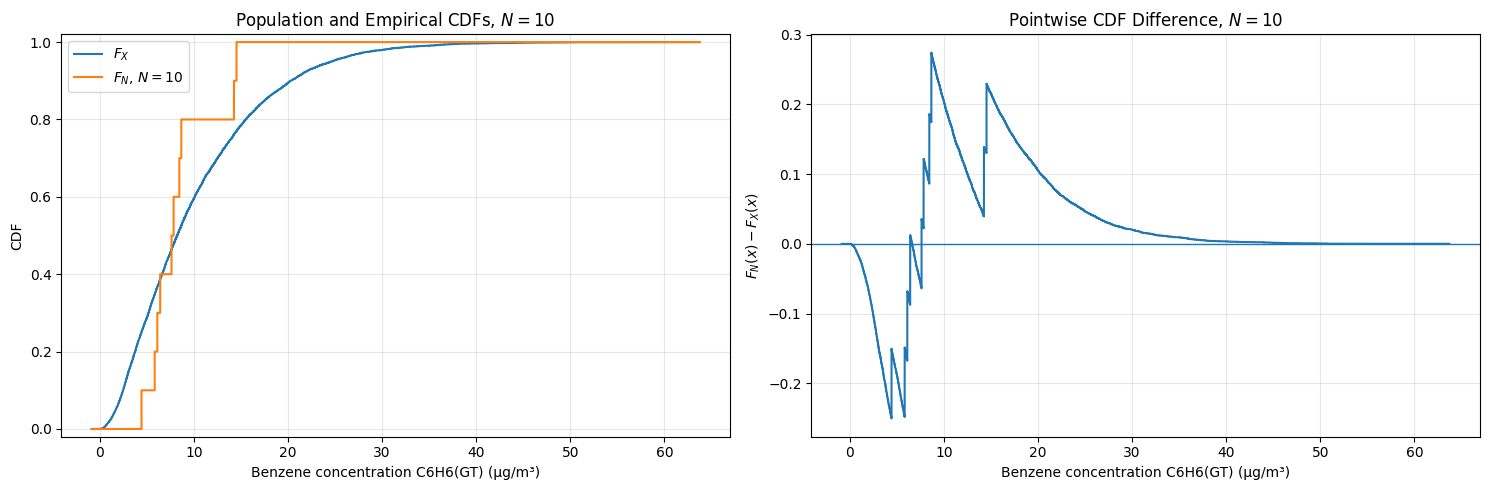

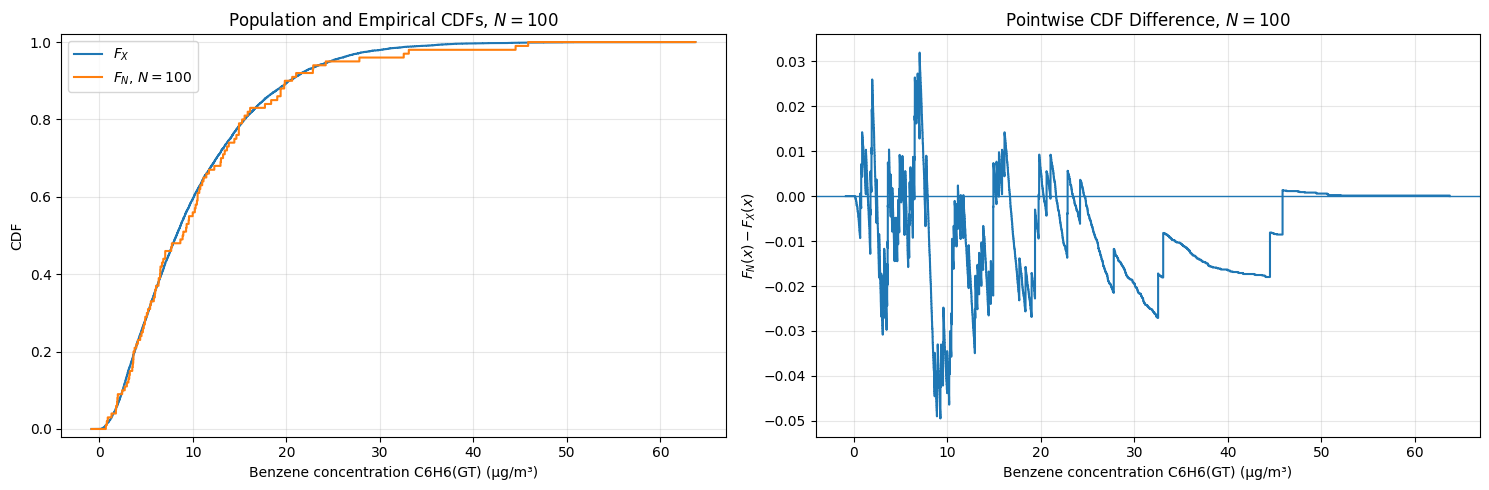

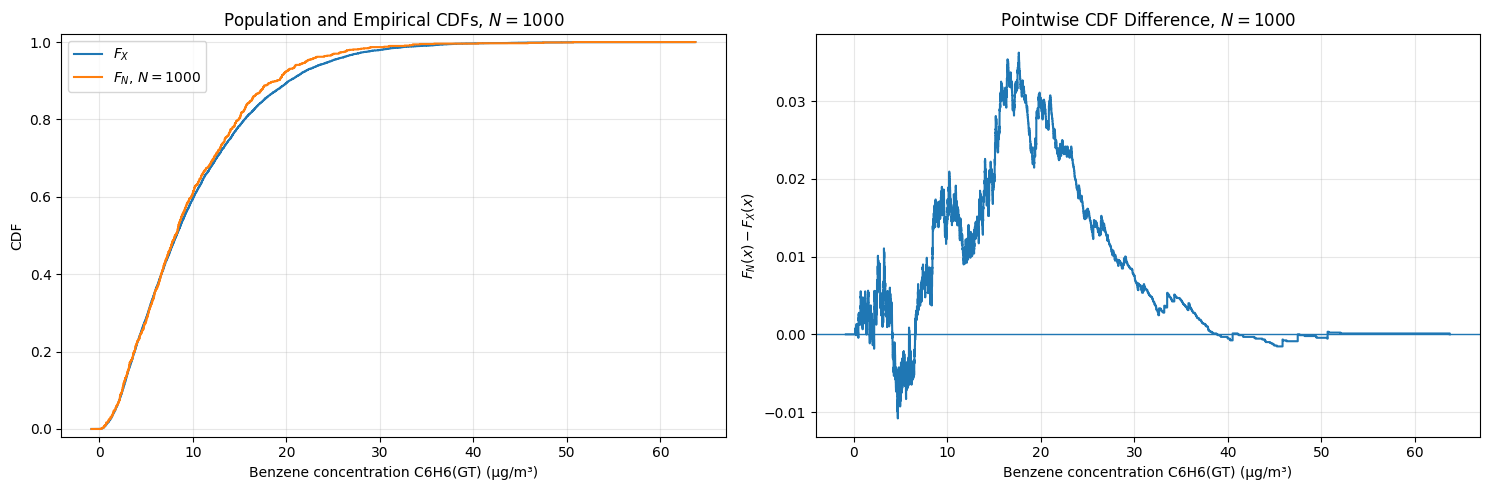

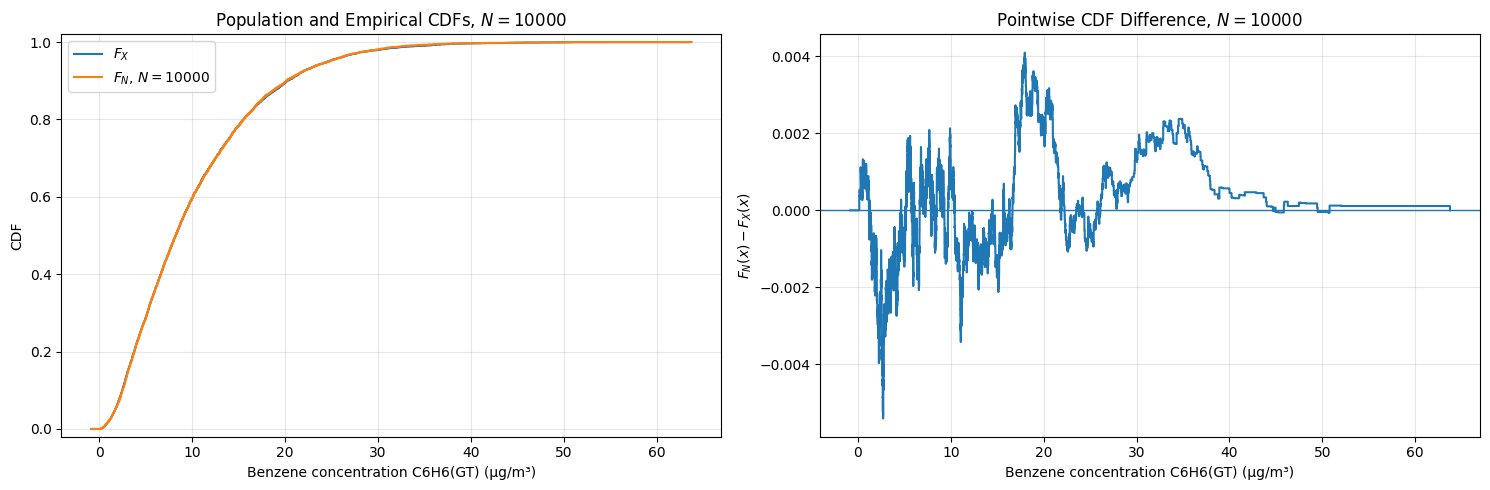

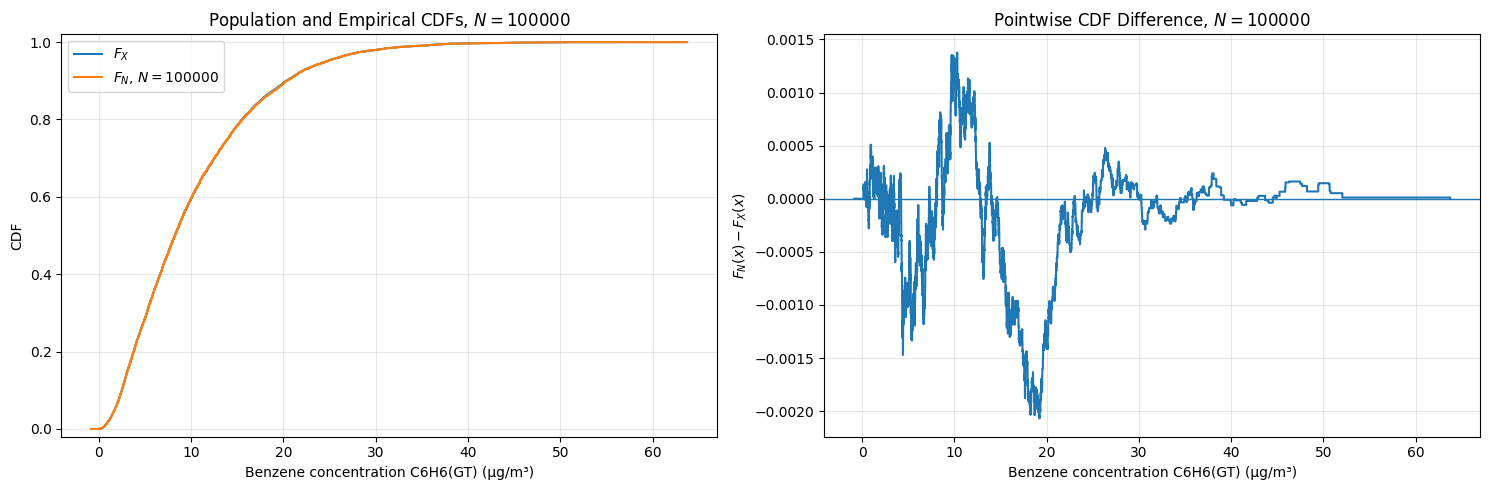

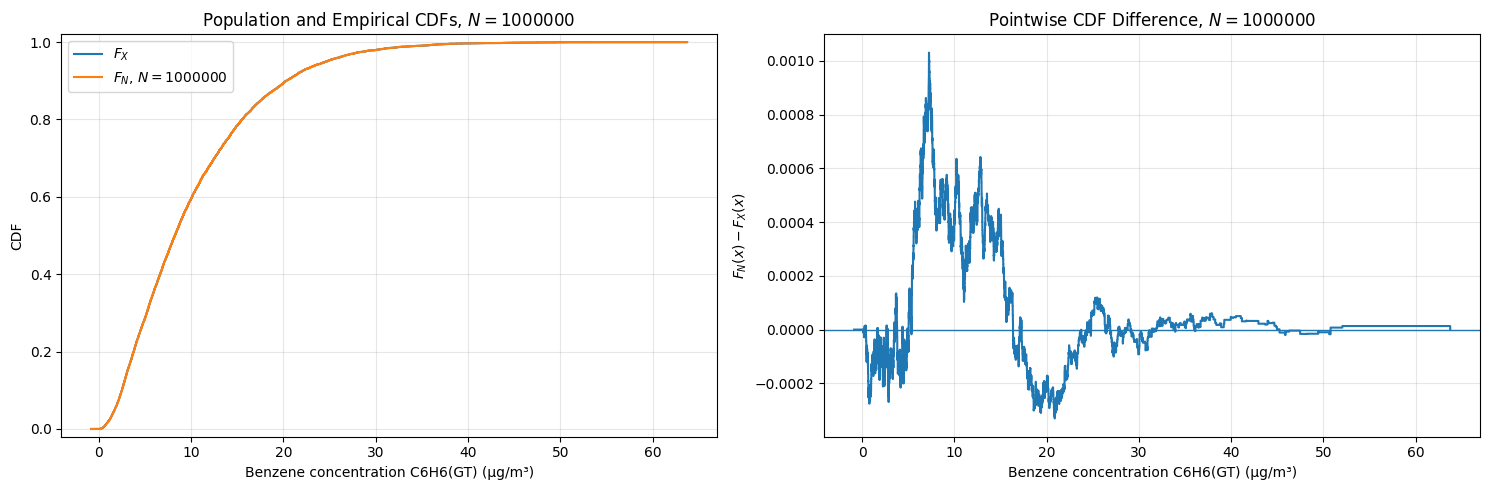

maximum absolute difference:
N =      10: 0.274252
N =     100: 0.049448
N =    1000: 0.036259
N =   10000: 0.005408
N =  100000: 0.002069
N = 1000000: 0.001031


In [51]:
# choose k = 6 so the largest sample size is 10^6
K = 6
RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)
sample_sizes = [10**k for k in range(1, K + 1)]

# make sure benzene values are stored as a numpy array
benzene_values = np.asarray(benzene)

# population size
population_size = len(benzene_values)

# add a starting point before the minimum value so the cdfs begin at 0
x_start = x_values[0] - 1

x_plot = np.concatenate(
    ([x_start], x_values)
)

F_plot = np.concatenate(
    ([0], F_X)
)

# store the maximum absolute difference for each sample size
max_errors = {}

for N in sample_sizes:

    # sample n observations independently and uniformly from the population
    # sampling is with replacement so repeated observations are possible
    sample_indices = rng.integers(
        0,
        population_size,
        size=N
    )

    # get the benzene values of the sampled observations
    sampled_values = benzene_values[sample_indices]

    # sort the sampled benzene values
    sampled_values_sorted = np.sort(sampled_values)

    # for each x count how many sampled values are less than or equal to x
    empirical_counts = np.searchsorted(
        sampled_values_sorted,
        x_values,
        side="right"
    )

    # empirical cdf f_n
    F_N = empirical_counts / N

    # difference between the empirical cdf and population cdf
    difference = F_N - F_X

    # maximum absolute difference for this sample size
    max_errors[N] = np.max(np.abs(difference))

    # add starting points so the plots begin at 0
    F_N_plot = np.concatenate(([0], F_N))
    difference_plot = np.concatenate(([0], difference))

    # plot the cdfs and their difference side by side
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))

    # population cdf and empirical cdf
    axes[0].step(
        x_plot,
        F_plot,
        where="post",
        label=r"$F_X$"
    )

    axes[0].step(
        x_plot,
        F_N_plot,
        where="post",
        label=rf"$F_N$, $N={N}$"
    )

    axes[0].set_xlabel("Benzene concentration C6H6(GT) (µg/m³)")
    axes[0].set_ylabel("CDF")
    axes[0].set_title(rf"Population and Empirical CDFs, $N={N}$")
    axes[0].set_ylim(-0.02, 1.02)
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    # difference between f_n and f_x
    axes[1].step(
        x_plot,
        difference_plot,
        where="post"
    )

    axes[1].axhline(0, linewidth=1)

    axes[1].set_xlabel("Benzene concentration C6H6(GT) (µg/m³)")
    axes[1].set_ylabel(r"$F_N(x)-F_X(x)$")
    axes[1].set_title(rf"Pointwise CDF Difference, $N={N}$")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

# print the maximum absolute difference for each sample size
print("maximum absolute difference:")

for N, error in max_errors.items():
    print(f"N = {N:>7}: {error:.6f}")

**Answer and findings.**  
_We choose a computationally feasible value of $K$, construct the empirical CDF $F_N$ for increasing sample sizes, and compare it with the population CDF $F_X$._

We chose $K=6$, so the sample sizes we considered were

$$
N\in\{10,10^2,10^3,10^4,10^5,10^6\}.
$$

This value of $K$ is computationally feasible because the largest experiment requires sampling and processing $10^6$ feature values. NumPy can efficiently store, sort, and process arrays of this size, so $K=6$ is a feasible value for this experiment.

For each value of $N$, we sample $N$ observations

$$
\omega_1,\ldots,\omega_N
\overset{\mathrm{i.i.d.}}{\sim}\mu.
$$

Since $\mu$ is the uniform measure on the population $\Omega$, every observation has the same probability of being selected on each draw. The draws are made independently with replacement, which also allows $N$ to be larger than the population size $M=8991$.

For each sampled observation, the random variable

$$
X(\omega_k)
$$

gives its benzene concentration. Using these sampled feature values, we construct the empirical CDF

$$
F_N(x)
=
\frac{1}{N}
\sum_{k=1}^{N}
\mathbf{1}_{\{X(\omega_k)\leq x\}}.
$$

The indicator

$$
\mathbf{1}_{\{X(\omega_k)\leq x\}}
$$

equals $1$ if the sampled benzene concentration is less than or equal to $x$, and equals $0$ otherwise. Therefore, $F_N(x)$ is the proportion of the $N$ sampled observations whose benzene concentration is at most $x$.

For each $N$, we compared the empirical CDF $F_N$ with the population CDF $F_X$, and also plotted the pointwise difference

$$
F_N(x)-F_X(x).
$$

A positive difference means that the sample contains a larger cumulative proportion of observations below $x$ than the full population, while a negative difference means that the sample contains a smaller cumulative proportion below $x$.

### Findings

For small values of $N$, the empirical CDF differs noticeably from the population CDF. For example, when $N=10$, the empirical CDF has only a small number of jumps and the maximum absolute difference is

$$
\max_x |F_N(x)-F_X(x)|
\approx 0.274252.
$$

This means a maximum difference of approximately $27.43$ percentage points.

As the sample size increases, the empirical CDF approximates the population CDF much more closely. The observed maximum absolute differences were

$$
\begin{array}{c|c}
N & \max_x |F_N(x)-F_X(x)|\\
\hline
10 & 0.274252\\
100 & 0.049448\\
1000 & 0.036259\\
10000 & 0.005408\\
100000 & 0.002069\\
1000000 & 0.001031
\end{array}
$$

In this exercise, the maximum difference decreases from approximately $27.43$ percentage points for $N=10$ to approximately $0.10$ percentage points for $N=10^6$.

This is clearly visible in the plots. For small $N$, the empirical CDF is more irregular and the difference $F_N-F_X$ in the pointwise difference plots has relatively large deviations from zero. As $N$ increases, the two CDF curves almost completely overlap and the difference plot becomes more concentrated around zero.

For a fixed value of $x$, define

$$
Y_k(x)
=
\mathbf{1}_{\{X(\omega_k)\leq x\}}.
$$

This checks whether the $k$-th sampled benzene value is less than or equal to $x$. If it is, the value is $1$, otherwise it is $0$.

Since the observations are sampled independently from $\mu$,

$$
P(Y_k(x)=1)
=
P(X(\omega_k)\leq x)
=
F_X(x).
$$

So,

$$
Y_k(x)\sim\operatorname{Bernoulli}(F_X(x)).
$$

The empirical CDF can then be written as

$$
F_N(x)
=
\frac{1}{N}
\sum_{k=1}^{N}Y_k(x).
$$

This is basically the proportion of sampled observations with benzene concentration less than or equal to $x$.

Therefore,

$$
E[F_N(x)]
=
F_X(x),
$$

and by the law of large numbers,

$$
F_N(x)\rightarrow F_X(x)
$$

in probability for each fixed $x$ as $N$ increases.

This is exactly what our plots show. For small $N$, the sample does not represent the full population as closely, so the difference between $F_N$ and $F_X$ is larger. As $N$ gets bigger, the sample becomes more representative and $F_N$ gets much closer to $F_X$.

With our dataset and setup, the maximum error decreased as $N$ increased. This does not mean it has to decrease every single time in every random experiment because the samples are random, but larger samples generally give a more accurate approximation of $F_X$ because random sampling variation becomes smaller as the sample size increases.

# Cross Validation

The following exercises compare two subsets of the population through their empirical cumulative distribution functions.

## Exercise 7 - Nearly equal partition

Let $M=|\Omega|$. Partition $\Omega$ into two disjoint sets of nearly equal cardinality:

$$
\Omega=\Omega_1\sqcup\Omega_2, \qquad
\left||\Omega_i|-\frac{M}{2}\right|\le\frac{1}{2}, \quad i\in\{1,2\}.
$$

Describe your partitioning method and verify the required cardinalities.

In [52]:
# Construct a nearly equal partition and verify its properties

# population size
M = len(dataset)

# randomly permute the population indices so there is no dependence on original ordering

indices = rng.permutation(M)

# split the indices into two nearly equal groups
split_point = M // 2

indices_1 = indices[:split_point]
indices_2 = indices[split_point:]

# construct two subsets of the population
omega_1 = dataset.iloc[indices_1]
omega_2 = dataset.iloc[indices_2]

# cardinalities
M_1 = len(omega_1)
M_2 = len(omega_2)

print("M =", M)
print("|omega_1| =", M_1)
print("|omega_2| =", M_2)

# check that both group sizes are as close to half of the population as possible
print("| |omega_1| - M/2 | =", abs(M_1 - M / 2))
print("| |omega_2| - M/2 | =", abs(M_2 - M / 2))

# check that the two subsets do not overlap and contain all observations
print("intersection size =", len(set(indices_1).intersection(set(indices_2))))
print("union size =", len(set(indices_1).union(set(indices_2))))

M = 8991
|omega_1| = 4495
|omega_2| = 4496
| |omega_1| - M/2 | = 0.5
| |omega_2| - M/2 | = 0.5
intersection size = 0
union size = 8991


**Answer.**  
_Describe the method and report the two cardinalities here._

Let $M = |\Omega|$. For the cleaned dataset

$$
M = 8991.
$$

Partitioning the dataset into two disjoint subsets of nearly equal size would have to satisfy the following properties:

$$
\Omega = \Omega_1 \sqcup \Omega_2.
$$

$$
\Omega_1 \cap \Omega_2 = \varnothing.
$$

Since \(M\) = 8991 it is odd and the population cannot be divided into two exactly equal halves.

$$
\frac{8991}{2} = 4495.5
$$

Because of this the closest integer group sizes we chose were

$$
|\Omega_1| = 4495, \qquad |\Omega_2| = 4496.
$$

So we get:

$$
|\Omega_1| = \left\lfloor \frac{M}{2} \right\rfloor = 4495
$$

and

$$
|\Omega_2| = \left\lceil \frac{M}{2} \right\rceil = 4496.
$$

To create the disjoint sets we permuted the observation indices and then split them into these two groups. We did this because it prevents the partition from depending on the original ordering of the dataset.

Because the two subsets are formed from non-overlapping parts of the same permutation, each observation from original $\Omega$ appears only once in either of the subsets and is never repeated.

$$
\Omega_1 \cap \Omega_2 = \varnothing.
$$

The additivity of the disjoint sets is

$$
\Omega = \Omega_1 \cup \Omega_2,
$$

so the cardinalities are additive

$$
|\Omega|
=
|\Omega_1 \cup \Omega_2|
=
|\Omega_1| + |\Omega_2|.
$$

Hence,

$$
8991 = 4495 + 4496.
$$

so every observation belongs to exactly one of the two subsets. Hence,

$$
\Omega = \Omega_1 \sqcup \Omega_2.
$$

To check that the two groups are as close to equal size as possible we compared each group size to half of the full population.

Since

$$
\frac{M}{2} = \frac{8991}{2} = 4495.5,
$$

and an exactly equal split is impossible we checked with the group sizes 4495 and 4496.

For $\Omega_1$,

$$
\left| |\Omega_1| - \frac{M}{2} \right|
=
|4495 - 4495.5|
=
\frac{1}{2}.
$$

For $\Omega_2$,

$$
\left| |\Omega_2| - \frac{M}{2} \right|
=
|4496 - 4495.5|
=
\frac{1}{2}.
$$

Both subsets are therefore exactly half an observation away from a perfect 50/50 split.

$$
\left| |\Omega_i| - \frac{M}{2} \right|
\leq
\frac{1}{2},
\qquad i \in \{1,2\}.
$$



## Exercise 8 - Bernoulli partition

Order the population as $\Omega=\{\omega_1,\ldots,\omega_M\}$. Let $B_1,\ldots,B_M$ be independent and identically distributed Bernoulli random variables with parameter $1/2$, and define

$$
\Omega_1=\{\omega_i:B_i=0\}, \qquad
\Omega_2=\{\omega_i:B_i=1\}.
$$

Do $\Omega_1$ and $\Omega_2$ satisfy the condition in Exercise 7 almost surely? What changes if the joint distribution of $(B_1,\ldots,B_M)$ is conditioned on

$$
\sum_{i=1}^{M}B_i=\left\lceil\frac{M}{2}\right\rceil?
$$


**Answer.**  
_Give a mathematical justification. Address the unconditional and conditioned constructions separately._

Using intependent Bernoulli random variables we assign each observation to one of the two subsets.

$$
B_1,\ldots,B_M \overset{\text{i.i.d.}}{\sim} \operatorname{Bernoulli}\left(\frac{1}{2}\right).
$$

For each observation $\omega_i\$,

$$
B_i = 0 \quad \Rightarrow \quad \omega_i \in \Omega_1,
$$

and

$$
B_i = 1 \quad \Rightarrow \quad \omega_i \in \Omega_2.
$$

Which means that for each observation if the Bernoilli value is 0 it is assigned to parition 1, otherwise it is assigned to paritition 2.

$$
\Omega_1 = \{\omega_i : B_i = 0\},
\qquad
\Omega_2 = \{\omega_i : B_i = 1\}.
$$

 Bernoulli variables can only take the value 0 or 1 and in this case with probability 1/2, so each observation is placed into exactly one of the two subsets.

Each observation is in at most one partition:
$$
\Omega_1 \cap \Omega_2 = \varnothing
$$

and the whole population is split up between two parititons using Bernoulli

$$
\Omega_1 \cup \Omega_2 = \Omega.
$$

This method, unlike question 7,  doesn't guarantee that the two subsets have nearly equal cardinalities.


The sum of independent Bernoulli random variables with the same parameter follow a binomal distribuion:

Let

$$
S=\sum_{i=1}^{M} B_i.
$$

For $(S=k)$, exactly \(k\) of the \(M\) Bernoulli variables must equal 1. There are

$$
\binom{M}{k}
$$

possible choices for these \(k\) variables. Since the $B_i\$'s are independent and

$$
P(B_i=1)=P(B_i=0)=\frac{1}{2},
$$

the probability of these arrangement is

$$
\left(\frac{1}{2}\right)^k
\left(\frac{1}{2}\right)^{M-k}.
$$

Therefore,

$$
P(S=k)
=
\binom{M}{k}
\left(\frac{1}{2}\right)^k
\left(\frac{1}{2}\right)^{M-k}
=
\binom{M}{k}
\left(\frac{1}{2}\right)^M.
$$

which is the probability mass fucntion of binomial distirbution.

$$
S\sim\operatorname{Binomial}\left(M,\frac{1}{2}\right).
$$
For our population, \(M=8991\), so

$$
S\sim\operatorname{Binomial}\left(8991,\frac{1}{2}\right).
$$

Therefore,

$$
P(S=k)
=
\binom{8991}{k}
\left(\frac{1}{2}\right)^{8991}.
$$

From Exercise 7, the nearly equal split only occurs when

$$
S\in\{4495,4496\}.
$$

So the probability of getting a nearly equal split is

$$
P(S=4495)+P(S=4496)
=
\left[
\binom{8991}{4495}
+
\binom{8991}{4496}
\right]
\left(\frac{1}{2}\right)^{8991}.
$$

Numerically,

$$
P(\text{nearly equal split})
\approx 0.01683,
$$

which is approximately \(1.68\%\).

Since this probability is much less than 1, the nearly equal condition does not hold almost surely.

$S$ counts how many observations are assigned to $\Omega_2$

$$
|\Omega_2| = S
$$

and

$$
|\Omega_1| = M-S.
$$

For our population,

$$
M = 8991.
$$

and in Exercise 7, the nearly equal condition requires the group sizes to be

$$
4495 \quad \text{and} \quad 4496.
$$

so the Bernoulli split satisfies the condition in Exercise 7 only when

$$
S \in \{4495,4496\}.
$$

Since

$$
S \sim \operatorname{Binomial}\left(8991,\frac{1}{2}\right),
$$

$S$ can take many values other than 4495 and 4496 with positive probability. Therefore,

$$
P\left(
\left||\Omega_i|-\frac{M}{2}\right|
\leq \frac{1}{2}
\text{ for } i=1,2
\right)
<1.
$$

Therefore, $\Omega_1$ and $\Omega_2$ do not satisfy the condition from exercise 7 almost surely, since the required event has probability strictly less than 1.  The independent Bernouilli assignemnts can make the split approximately balanced but not guaranteed a neear equal split like in exercise 7.


Now consider conditioning the joint distribution on

$$
\sum_{i=1}^{M} B_i
=
\left\lceil \frac{M}{2} \right\rceil.
$$

Since

$$
\left\lceil \frac{8991}{2} \right\rceil = 4496,
$$

the conditioning forces

$$
\sum_{i=1}^{M} B_i = 4496.
$$

Therefore, exactly 4496 observations are assigned to $\Omega_2\$:

$$
|\Omega_2| = 4496.
$$

The remaining observations must belong to $\Omega_1$, so

$$
|\Omega_1|
=
8991-4496
=
4495.
$$

Hence,

$$
\left||\Omega_1|-\frac{M}{2}\right|
=
\frac{1}{2}
$$

and

$$
\left||\Omega_2|-\frac{M}{2}\right|
=
\frac{1}{2}.
$$

So under the conditioned distribution the condition of near equal split form exercise 7 can be satisifed with probability 1.

Under the conditioned distribution, the variables are no longer i.i.d. Bernoulli\((1/2)\), because the total number of ones is fixed.

Therefore, conditioning changes the procedure from independent Bernoulli assignment to a random partition with fixed group sizes

$$
|\Omega_1|=4495,
\qquad
|\Omega_2|=4496.
$$

In our simulation the unconditional Bernoulli partition gave

$$
|\Omega_1|=4441,
\qquad
|\Omega_2|=4550.
$$

Therefore, neither subset satisfied the nearly equal condition from Exercise 7, which agrees with the explanation above.

In [57]:
# Optional: use a simulation to illustrate your theoretical answer.

# population size
M = len(dataset)
RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)
# generate one bernoulli value for every observation
# 0 assigns the observation to omega_1 and 1 assigns it to omega_2
B = rng.binomial(1, 0.5, size=M)

# get the indices belonging to each partition
omega_1_indices = np.where(B == 0)[0]
omega_2_indices = np.where(B == 1)[0]

# cardinalities of the unconditional bernoulli partition
print("unconditional bernoulli partition:")
print("|omega_1| =", len(omega_1_indices))
print("|omega_2| =", len(omega_2_indices))

# check if both group sizes satisfy the nearly equal condition from exercise 7
print(
    "condition for omega_1:",
    abs(len(omega_1_indices) - M / 2) <= 0.5
)

print(
    "condition for omega_2:",
    abs(len(omega_2_indices) - M / 2) <= 0.5
)


# conditioned bernoulli partition

# fix the number of ones to m/2
num_ones = int(np.ceil(M / 2))

# randomly choose exactly num_ones observations to belong to omega_2
conditioned_indices_2 = rng.choice(
    M,
    size=num_ones,
    replace=False
)

# all remaining observations belong to omega_1
zeros = np.zeros(M, dtype=bool)
zeros[conditioned_indices_2] = True

conditioned_indices_1 = np.where(~zeros)[0]

# cardinalities of the conditioned partition
print("\nconditioned bernoulli partition:")
print("|omega_1| =", len(conditioned_indices_1))
print("|omega_2| =", len(conditioned_indices_2))

# check if both group sizes satisfy the nearly equal condition from exercise 7
print(
    "condition for omega_1:",
    abs(len(conditioned_indices_1) - M / 2) <= 0.5
)

print(
    "condition for omega_2:",
    abs(len(conditioned_indices_2) - M / 2) <= 0.5
)

unconditional bernoulli partition:
|omega_1| = 4441
|omega_2| = 4550
condition for omega_1: False
condition for omega_2: False

conditioned bernoulli partition:
|omega_1| = 4495
|omega_2| = 4496
condition for omega_1: True
condition for omega_2: True


## Exercise 9 - Comparing random partitions

Sample $B_1,\ldots,B_M$ i.i.d. Bernoulli random variables with parameter $1/2$. Let

$$
\Omega_1=\{\omega_i:B_i=0\}, \qquad
\Omega_2=\{\omega_i:B_i=1\}.
$$

If either $\Omega_1$ or $\Omega_2$ is empty, resample them. Let

$$
F_1(x)=\frac{1}{|\Omega_1|}\sum_{\omega\in\Omega_1}\mathbf{1}_{\{X(\omega)\le x\}},
\qquad
F_2(x)=\frac{1}{|\Omega_2|}\sum_{\omega\in\Omega_2}\mathbf{1}_{\{X(\omega)\le x\}}.
$$

1. Plot the difference $F_1-F_2$.
2. Plot $F_2-F_X$.
3. Is $F_2$ enough to understand $F_X$? Explain.


|Omega_1| = 4441
|Omega_2| = 4550


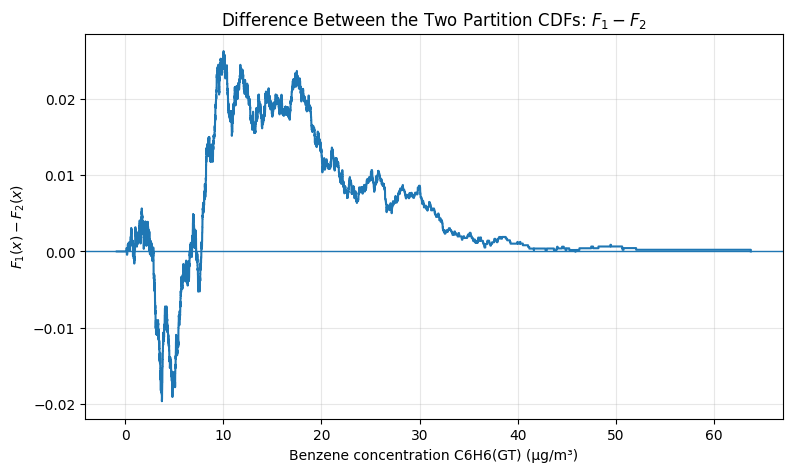

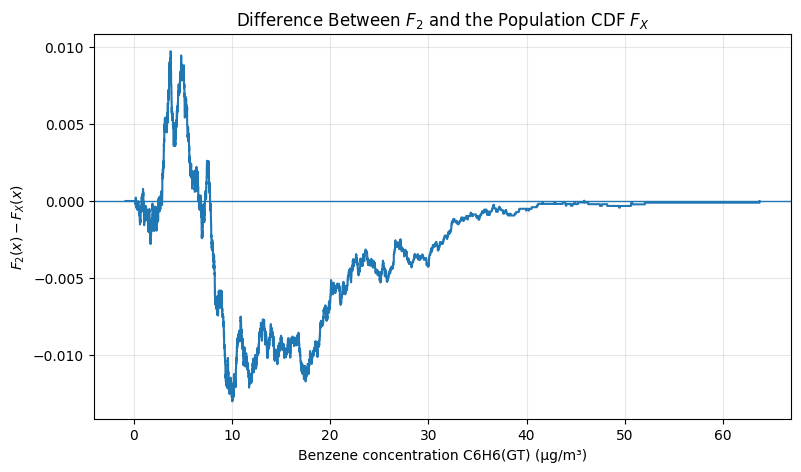

Maximum |F_1 - F_2| = 0.026283061680494657
Maximum |F_2 - F_X| = 0.012982212982210806


In [59]:
# Create the Bernoulli partition and produce both requested difference plots.

M = len(dataset)
RANDOM_SEED = 2026
rng = np.random.default_rng(RANDOM_SEED)

# generating the bernouli patition
while True:
    B = rng.binomial(1, 0.5, size=M) #bernouilli

    indices_1 = np.where(B == 0)[0]
    indices_2 = np.where(B == 1)[0]

    if len(indices_1) > 0 and len(indices_2) > 0:
        break

# split up the benzene features
X_1 = benzene[indices_1]
X_2 = benzene[indices_2]

print("|Omega_1| =", len(X_1))
print("|Omega_2| =", len(X_2))

# empirical f1 and f2 distirbutions
# sorting values so it is easier to count how many values <=x
X_1_sorted = np.sort(X_1)
X_2_sorted = np.sort(X_2)

# empirical cdf on f1 and f2, side right counts vaqlues equal to x too
F_1 = np.searchsorted(
    X_1_sorted,
    x_values,
    side="right"
) / len(X_1)

F_2 = np.searchsorted(
    X_2_sorted,
    x_values,
    side="right"
) / len(X_2)


# difference between f1 and f2
difference_12 = F_1 - F_2

# difference between f2 and fx
difference_2X = F_2 - F_X

# adding starting points
difference_12_plot = np.concatenate(([0], difference_12))
difference_2X_plot = np.concatenate(([0], difference_2X))

#plotting f1 vs f2
plt.figure(figsize=(9, 5))

plt.step(
    x_plot,
    difference_12_plot,
    where="post"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Benzene concentration C6H6(GT) (µg/m³)")
plt.ylabel(r"$F_1(x)-F_2(x)$")
plt.title(r"Difference Between the Two Partition CDFs: $F_1-F_2$")
plt.grid(alpha=0.3)

plt.show()

# plotting f2 and fx

plt.figure(figsize=(9, 5))

plt.step(
    x_plot,
    difference_2X_plot,
    where="post"
)

plt.axhline(0, linewidth=1)

plt.xlabel("Benzene concentration C6H6(GT) (µg/m³)")
plt.ylabel(r"$F_2(x)-F_X(x)$")
plt.title(r"Difference Between $F_2$ and the Population CDF $F_X$")
plt.grid(alpha=0.3)

plt.show()


# maximum differences between the two graphs

print(
    "Maximum |F_1 - F_2| =",
    np.max(np.abs(difference_12))
)

print(
    "Maximum |F_2 - F_X| =",
    np.max(np.abs(difference_2X))
)

**Answer and interpretation.**  
_Interpret both difference plots and answer whether $F_2$ is enough to understand $F_X$._

The Bernoulli partition produced

$$
|\Omega_1|=4441
$$

and

$$
|\Omega_2|=4550.
$$

Since

$$
4441+4550=8991=M,
$$

the two subsets together contain the full population, with no overlapping observations.

The first plot shows

$$
F_1(x)-F_2(x).
$$

This measures the difference between the proportions of observations in the two partitions that have benzene concentration less than or equal to $x$.

A positive value on this graph means that a larger proportion of $\Omega_1$ is below that benzene concentration, while a negative value means that a larger proportion of $\Omega_2$ is below it.

The difference remains close to zero over the full range of benzene concentrations. The largest absolute difference was

$$
\max_x |F_1(x)-F_2(x)|
\approx 0.0262.
$$

This means that at the point where the two empirical CDFs differ the most, their cumulative proportions differ by approximately

$$
2.62\%.
$$

These differences happen because the Bernoulli partition is random. Even though every observation has probability $1/2$ of being assigned to either subset, the two subsets will not contain exactly the same proportions of every benzene concentration.

The second plot shows

$$
F_2(x)-F_X(x),
$$

which compares the empirical CDF from the second partition with the CDF of the full population.

A positive value means that $F_2(x)$ is above the population CDF at that value of $x$, while a negative value means that it is below it.

The maximum absolute difference was

$$
\max_x |F_2(x)-F_X(x)|
\approx 0.0129.
$$

In this random partition, the empirical CDF of $\Omega_2$ differs from the population CDF by at most approximately

$$
1.29\%.
$$

This shows that $F_2$ gives a close representation of the full population CDF in this particular experiment.

The relationship between the two plots can also be represented using

$$
\Omega=\Omega_1\sqcup\Omega_2.
$$

The full population empirical CDF can be separated into the contributions from the two subsets:

$$
F_X(x)
=
\frac{|\Omega_1|}{M}F_1(x)
+
\frac{|\Omega_2|}{M}F_2(x).
$$

Therefore,

$$
F_2(x)-F_X(x)
=
F_2(x)
-
\frac{|\Omega_1|}{M}F_1(x)
-
\frac{|\Omega_2|}{M}F_2(x).
$$

Since

$$
\frac{|\Omega_1|+|\Omega_2|}{M}=1,
$$

this becomes

$$
F_2(x)-F_X(x)
=
\frac{|\Omega_1|}{M}
\left(
F_2(x)-F_1(x)
\right).
$$

For this partition,

$$
\frac{|\Omega_1|}{M}
=
\frac{4441}{8991}
\approx 0.493.
$$

Hence,

$$
\max_x|F_2(x)-F_X(x)|
=
\frac{4441}{8991}
\max_x|F_1(x)-F_2(x)|.
$$

Using the observed maximum difference,

$$
0.493(0.0262)
\approx
0.0129,
$$

which matches the result from the second plot.

Therefore, $F_2$ is approximately half as far from $F_X$ as $F_1$ is from $F_2$, because $F_X$ is a weighted combination of $F_1$ and $F_2$ and the two subsets are close to equal in size.

However, $F_2$ by itself is not enough to determine the full population CDF exactly. The exact value of $F_X$ also depends on $F_1$ and on the sizes of the two subsets. In this experiment, $F_2$ gives a good approximation of $F_X$, but it does not contain all the information needed to reconstruct $F_X$ exactly.